In [260]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime
%matplotlib notebook
%matplotlib inline
pd.options.display.max_rows = 150

In [261]:
reference_date_str = "2026-02-28"
reference_year = 2026
reference_month = 2
reference_day = 28

In [262]:
county = "US"

In [263]:
is_va_str = "no_VA"

In [264]:
start = datetime.date(reference_year+1, reference_month, reference_day)
end = datetime.date(reference_year+49, reference_month, reference_day)

In [265]:
current_dir = os.getcwd()

In [266]:
data_dir = current_dir + "\\data"

In [267]:
Qb_path = os.path.join(data_dir,"qb_vectors.csv")

In [268]:
all_Qb = pd.read_csv(Qb_path, header=0)

In [269]:
all_Qb.head()

,reference_date,curve_type,country,term_index,qb_value
0,2014-12-31,no_VA,AT,1.0,-1.939468
1,2014-12-31,no_VA,AT,2.0,0.897682
2,2014-12-31,no_VA,AT,3.0,-0.309434
3,2014-12-31,no_VA,AT,4.0,0.380559
4,2014-12-31,no_VA,AT,5.0,-0.007954


In [270]:
one_Qb = all_Qb[
    (all_Qb["reference_date"] == reference_date_str) &
    (all_Qb["country"] == county) &
    (all_Qb["curve_type"] == is_va_str)
]

In [271]:
one_Qb.head()

,reference_date,curve_type,country,term_index,qb_value
373613,2026-02-28,no_VA,US,1.0,-24.608731
373614,2026-02-28,no_VA,US,2.0,15.776474
373615,2026-02-28,no_VA,US,3.0,-1.400574
373616,2026-02-28,no_VA,US,4.0,-0.763564
373617,2026-02-28,no_VA,US,5.0,1.286654


In [272]:
param_path = os.path.join(data_dir,"curve_parameters.csv")

In [273]:
all_params = pd.read_csv(param_path, header=0)

In [274]:
all_params.head()

,reference_date,curve_type,country,instrument_type,coupon_freq,llp,convergence,ufr,alpha,cra,va
0,2014-12-31,no_VA,AT,SWP,1.0,20.0,40.0,4.2,0.129489,10.0,0.0
1,2014-12-31,no_VA,AUD,SWP,2.0,30.0,40.0,4.2,0.103482,35.0,0.0
2,2014-12-31,no_VA,BE,SWP,1.0,20.0,40.0,4.2,0.129489,10.0,0.0
3,2014-12-31,no_VA,BGN,SWP,1.0,20.0,40.0,4.2,0.130023,15.0,0.0
4,2014-12-31,no_VA,BRL,GVT,0.0,10.0,50.0,5.2,0.138381,35.0,0.0


In [275]:
one_param = all_params[
    (all_params["reference_date"] == reference_date_str) &
    (all_params["country"] == county) &
    (all_params["curve_type"] == is_va_str)
]

In [276]:
display(one_param)

,reference_date,curve_type,country,instrument_type,coupon_freq,llp,convergence,ufr,alpha,cra,va
13924,2026-02-28,no_VA,US,OIS,1.0,30.0,40.0,3.3,0.087543,0.0,NaN


In [277]:
ufr = one_param.loc[:,"ufr"].values[0]/100

In [278]:
alpha = one_param.loc[:,"alpha"].values[0]

## Curve of interest

In [279]:
M_Target =  np.transpose(np.arange(1,50))

In [280]:
one_Qb.head()

,reference_date,curve_type,country,term_index,qb_value
373613,2026-02-28,no_VA,US,1.0,-24.608731
373614,2026-02-28,no_VA,US,2.0,15.776474
373615,2026-02-28,no_VA,US,3.0,-1.400574
373616,2026-02-28,no_VA,US,4.0,-0.763564
373617,2026-02-28,no_VA,US,5.0,1.286654


In [281]:
periods_date = pd.date_range(start = start, end = end, periods = M_Target.shape[0], unit=None)

In [282]:
Qb = one_Qb.loc[:,"qb_value"].values

In [283]:
display(Qb)

array([-2.46087305e+01,  1.57764741e+01, -1.40057392e+00, -7.63564460e-01,
        1.28665411e+00,  6.20025845e-02, -6.51961759e-01,  2.42882063e-01,
        5.81540307e-02,  5.96151542e-02, -1.42257006e-02,  1.29943120e-01,
       -1.84013864e-02, -1.78135396e-02, -1.89166298e-01, -1.04150253e-02,
       -1.00823091e-02, -9.76022178e-03, -9.44842380e-03, -1.61185543e-01,
       -3.12974948e-03, -3.02976717e-03, -2.93297887e-03, -2.83928254e-03,
       -1.76775204e-01,  3.93859202e-03,  3.81277059e-03,  3.69096863e-03,
        3.57305772e-03,  9.21194517e-02])

In [284]:
M_Obs = np.transpose(np.array(list(one_Qb.loc[:,"term_index"].values)))

In [285]:
display(M_Obs)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30.])

In [286]:
def SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha):
# SWEXTRAPOLATE Interpolate or/and extrapolate rates for targeted maturities using a Smith-Wilson algorithm.
# out = SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha) calculates the rates for maturities specified in M_Target using the calibration vector b.
#
# Arguments: 
#    M_Target = k x 1 ndarray. Each element represents a bond maturity of interest. Ex. M_Target = [[1], [2], [3], [5]]
#    M_Obs =    n x 1 ndarray. Observed bond maturities used for calibrating the calibration vector b. Ex. M_Obs = [[1], [3]]
#    Qb =       n x 1 ndarray. Calibration vector calculated on observed bonds.
#    ufr =      1 x 1 floating number. Representing the ultimate forward rate.
#       Ex. ufr = 0.042
#    alpha =    1 x 1 floating number. Representing the convergence speed parameter alpha. Ex. alpha = 0.05
# 
#
# Returns:
#    k x 1 ndarray. Represents the targeted rates for a zero-coupon bond. Each rate belongs to a targeted zero-coupon bond with a maturity from T_Target. Ex. r = [0.0024; 0.0029; 0.0034; 0.0039]
#
# For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

    def SWHeart(u, v, alpha):
    # SWHEART Calculate the heart of the Wilson function.
    # H = SWHeart(u, v, alpha) calculates the matrix H (Heart of the Wilson
    # function) for maturities specified by vectors u and v. The formula is
    # taken from the EIOPA technical specifications paragraph 132.
    #
    # Arguments:  
    #    u =     n_1 x 1 vector of maturities. Ex. u = [1; 3]
    #    v =     n_2 x 1 vector of maturities. Ex. v = [1; 2; 3; 5]
    #    alpha = 1 x 1 floating number representing the convergence speed parameter alpha. Ex. alpha = 0.05
    #
    # Returns:
    #    n_1 x n_2 matrix representing the Heart of the Wilson function for selected maturities and parameter alpha. H is calculated as in the paragraph 132 of the EIOPA documentation. 
    #
    # For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

        u_Mat = np.tile(u, [v.size, 1]).transpose()
        v_Mat = np.tile(v, [u.size, 1])
        return 0.5 * (alpha * (u_Mat + v_Mat) + np.exp(-alpha * (u_Mat + v_Mat)) - alpha * np.absolute(u_Mat-v_Mat) - np.exp(-alpha * np.absolute(u_Mat-v_Mat))); # Heart of the Wilson function from paragraph 132

    H = SWHeart(M_Target, M_Obs, alpha) # Heart of the Wilson function from paragraph 132
    p = np.exp(-np.log(1+ufr)* M_Target) + np.diag(np.exp(-np.log(1+ufr) * M_Target)) @ H @ Qb # Discount pricing function for targeted maturities from paragraph 147
    return p ** (-1/ M_Target) -1 # Convert obtained prices to rates and return prices

In [287]:
r_Target = SWExtrapolate(M_Target,M_Obs, Qb, ufr, alpha)
r_Target = pd.DataFrame(r_Target,columns=['Recalculated rates'], index = M_Target)

In [288]:
r_Target.head()

,Recalculated rates
1,0.034195
2,0.032039
3,0.031622
4,0.031869
5,0.032352


## Import curve

In [290]:
curves_path = os.path.join(data_dir,"yield_curves.csv")

In [291]:
all_curves = pd.read_csv(curves_path, header=0)

In [316]:
all_curves.head()

,reference_date,curve_type,country,term_index,spot_rate
0,2014-12-31,no_VA,AT,1.0,0.00062
1,2014-12-31,no_VA,AT,2.0,0.00075
2,2014-12-31,no_VA,AT,3.0,0.00120
3,2014-12-31,no_VA,AT,4.0,0.00184
4,2014-12-31,no_VA,AT,5.0,0.00261


In [293]:
one_curve = all_curves[
    (all_curves["reference_date"] == reference_date_str) &
    (all_curves["country"] == county) &
    (all_curves["curve_type"] == is_va_str)
]

In [294]:
one_curve.head()

,reference_date,curve_type,country,term_index,spot_rate
2088600,2026-02-28,no_VA,US,1.0,0.03419
2088601,2026-02-28,no_VA,US,2.0,0.03204
2088602,2026-02-28,no_VA,US,3.0,0.03162
2088603,2026-02-28,no_VA,US,4.0,0.03187
2088604,2026-02-28,no_VA,US,5.0,0.03235


In [307]:
one_curve = one_curve.iloc[:periods_date.shape[0],:]

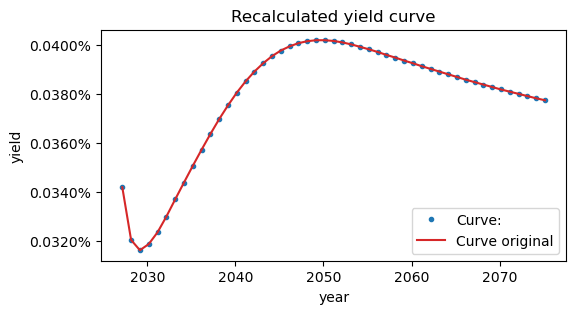

In [315]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(periods_date, r_Target.values, color='tab:blue',label="Curve:", marker='.', linestyle='')
ax1.plot(periods_date, one_curve.loc[:,["spot_rate"]].values, color='tab:red',label="Curve original",  linestyle='-')

ax1.set_ylabel("yield")
ax1.set_title('Recalculated yield curve')
ax1.set_xlabel("year")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()